In [294]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import flask

print("Setup successful!")

Setup successful!


In [383]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("patient_data.csv")

data.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [385]:
data.isnull().sum()


C                  0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64

In [387]:
data.rename(columns={'C':'Gender'}, inplace=True)

In [389]:
data['TakeMedication'].replace({'Yes ':'Yes'}, inplace=True)

data['NoseBleeding'].replace({'No ':'No'}, inplace=True)

data['Systolic'].replace({'121- 130':'121 - 130'}, inplace=True)

data['Systolic'].replace({'100+':'100 - 110'}, inplace=True)

data['Stages'].replace({'HYPERTENSION (Stage-2)':'HYPERTENSION (Stage-2)'}, inplace=True)

data['Stages'].replace({'HYPERTENSIVE CRISIS':'HYPERTENSIVE CRISIS'}, inplace=True)

print((data['Diastolic']=='130+').sum())

print((data['Diastolic']=='100+').sum())

data['Diastolic'].replace({'130+':'100+'}, inplace=True)

4
237


C:\Users\admin\AppData\Local\Temp\ipykernel_19788\1343638106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TakeMedication'].replace({'Yes ':'Yes'}, inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_19788\1343638106.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [391]:
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

476


C:\Users\admin\AppData\Local\Temp\ipykernel_19788\5144992.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Gender", palette="Set2")


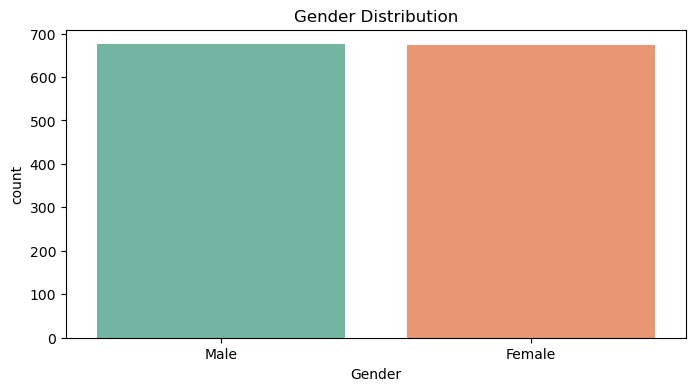

In [393]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()

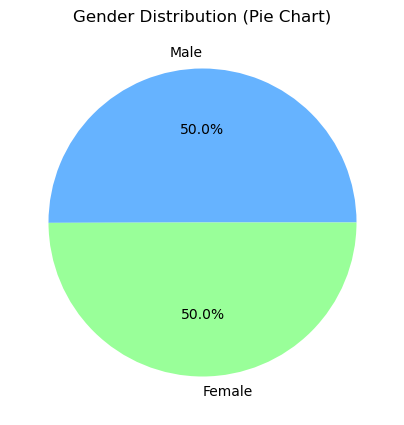

In [395]:
data["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(5,5),
    colors=["#66b3ff","#99ff99"]
)

plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

In [397]:
data["Stages"] = data["Stages"].str.strip()

data["Stages"] = data["Stages"].replace({
    "HYPERTENSION (Stage-2).": "HYPERTENSION (Stage-2)",
    "HYPERTENSIVE CRISI": "HYPERTENSIVE CRISIS"
})
print(data["Stages"].unique())

['HYPERTENSION (Stage-1)' 'HYPERTENSION (Stage-2)' 'HYPERTENSIVE CRISIS'
 'NORMAL']


C:\Users\admin\AppData\Local\Temp\ipykernel_19788\3132479274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Stages", palette="coolwarm")


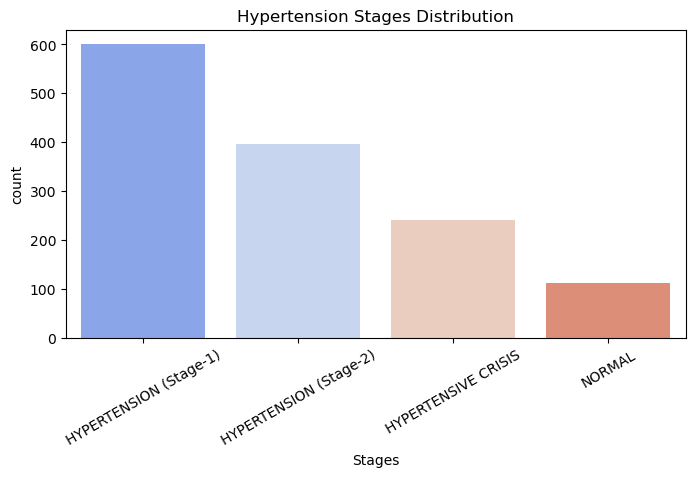

In [357]:
plt.figure(figsize=(8,4))

sns.countplot(data=data, x="Stages", palette="coolwarm")

plt.title("Hypertension Stages Distribution")

plt.xticks(rotation=30)

plt.show()

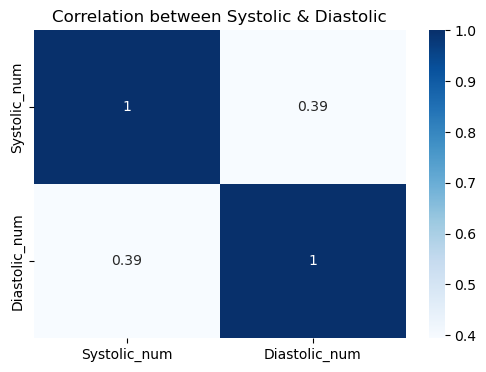

In [399]:
import numpy as np

def range_to_midpoint(val):

    if "-" in val:
        start, end = val.split("-")
        return (int(start.strip()) + int(end.strip())) / 2

    elif "+" in val:
        return int(val.replace("+","").strip())

    else:
        return np.nan


data["Systolic_num"] = data["Systolic"].apply(range_to_midpoint)

data["Diastolic_num"] = data["Diastolic"].apply(range_to_midpoint)
plt.figure(figsize=(6,4))

sns.heatmap(
    data[["Systolic_num","Diastolic_num"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation between Systolic & Diastolic")

plt.show()

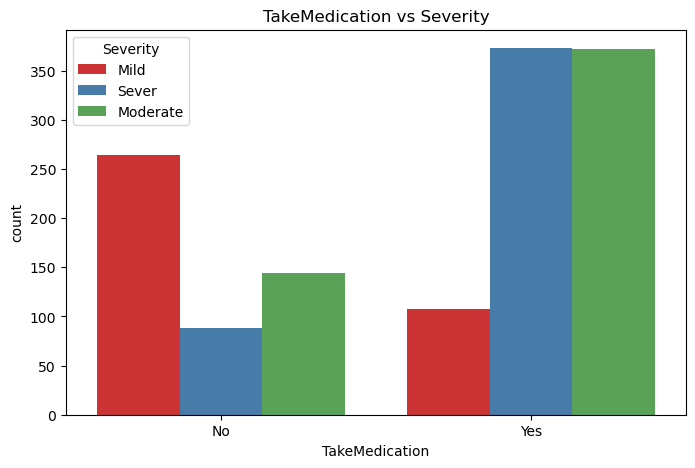

In [401]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="TakeMedication",
    hue="Severity",
    palette="Set1"
)

plt.title("TakeMedication vs Severity")

plt.show()

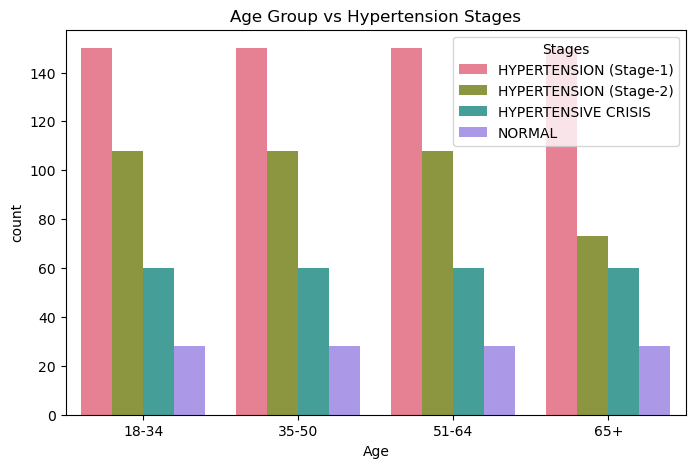

In [403]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="Age",
    hue="Stages",
    palette="husl"
)

plt.title("Age Group vs Hypertension Stages")

plt.show()

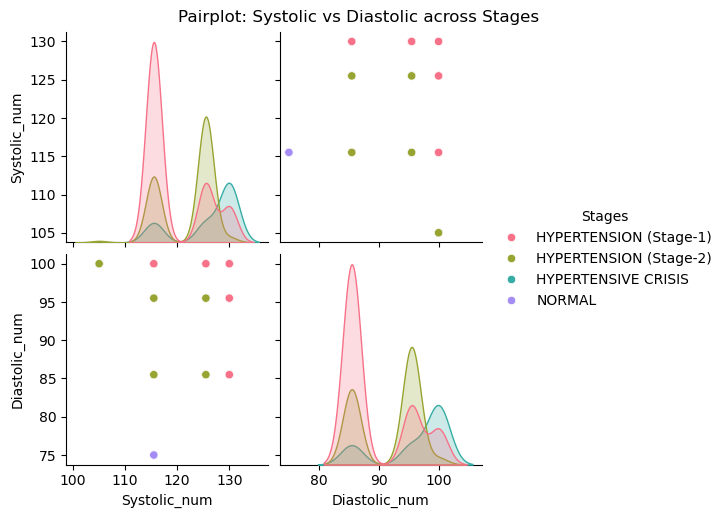

In [405]:
sns.pairplot(
    data[["Systolic_num","Diastolic_num","Stages"]],
    hue="Stages",
    diag_kind="kde",
    palette="husl"
)

plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)

plt.show()